In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

import pickle

In [ ]:
df = pd.read_csv("/content/car data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
df.columns = df.columns.str.strip().str.lower()

current_year = 2024
df['no_year'] = current_year - df['year']

df.drop(['car_name','year'], axis=1, inplace=True)

df.isnull().sum()

,0
selling_price,0
present_price,0
kms_driven,0
fuel_type,0
seller_type,0
transmission,0
owner,0
no_year,0


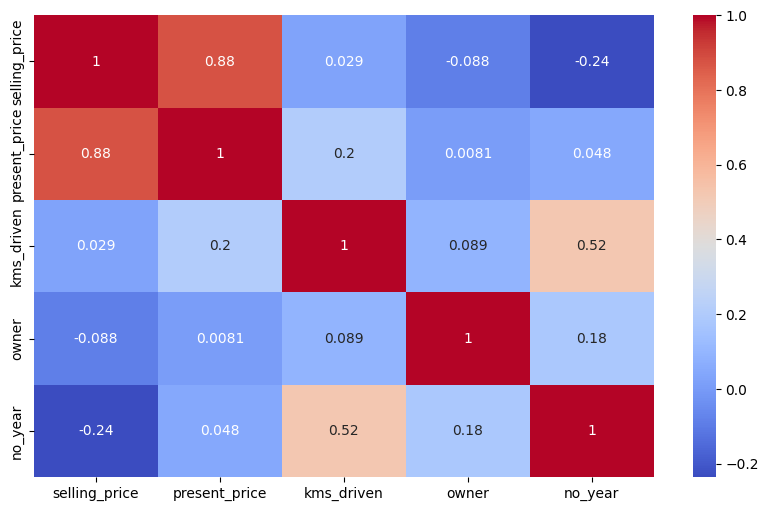

In [ ]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

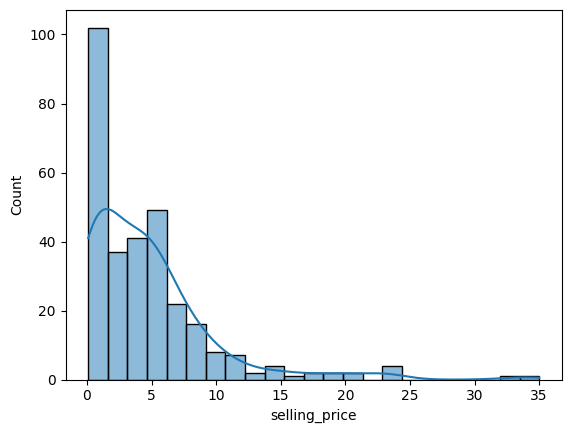

In [ ]:
sns.histplot(df['selling_price'], kde=True)
plt.show()

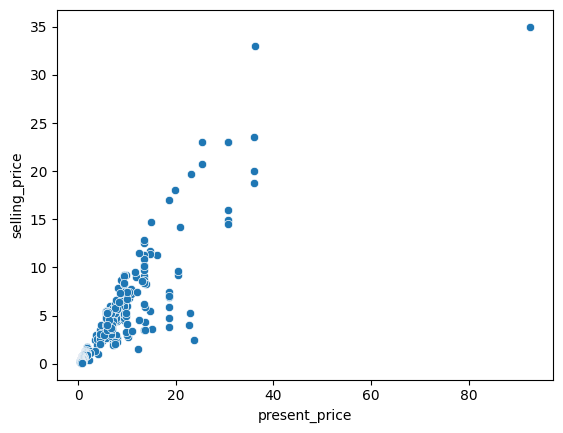

In [ ]:
sns.scatterplot(x=df['present_price'], y=df['selling_price'])
plt.show()

In [ ]:
X = df.drop('selling_price', axis=1)
y = df['selling_price']

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
print("Linear Regression R2:", r2_score(y_test, y_pred))

Linear Regression R2: 0.848981302489908


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

RandomForestRegressor()

In [ ]:
pickle.dump(rf, open("car_model.pkl", "wb"))

In [ ]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

pickle.dump(rf, open("car_model.pkl", "wb"))

In [ ]:
!ls

'car data.csv'	 car_model.pkl	 sample_data
